<a href="https://colab.research.google.com/github/ShreyaKantamsetty/bank-campaign-prediction/blob/main/notebooks/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, roc_auc_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42     # fixed seed for reproducibility

# Load the data and rebuild the SAME train/holdout split

In [5]:
from google.colab import files

if not os.path.exists('bank-additional-full.csv'):
    print("Choose bank-additional-full.csv (the full 41,188-row file)")
    files.upload()

raw = pd.read_csv('bank-additional-full.csv', sep=';')
df = raw.drop_duplicates().reset_index(drop=True)       # same cleaning as Task 1
y_all = (df['y'] == 'yes').astype(int)                  # kept separately; never used for clustering

split_idx = int(len(df) * 0.8)                          # same time-ordered 80/20 split as Task 1
train_df = df.iloc[:split_idx].reset_index(drop=True)
holdout_df = df.iloc[split_idx:].reset_index(drop=True)
y_train = y_all.iloc[:split_idx].reset_index(drop=True)
y_holdout = y_all.iloc[split_idx:].reset_index(drop=True)

print(raw.shape, '->', df.shape, '| train', train_df.shape, '| holdout', holdout_df.shape)
assert (len(train_df), len(holdout_df)) == (32940, 8236), \
    "Split differs from Task 1 (expected 32,940 train / 8,236 holdout). Fix this before continuing."

(41188, 21) -> (41176, 21) | train (32940, 21) | holdout (8236, 21)


# Define your unit and Feature Selection

**Unit of clustering:** contact records (rows), not unique people. The file has no dependable customer ID, and the same client may appear in several rows from different contacts.

**Features used (9):**
- Client attributes: `age`, `job`, `marital`, `education`, `default`, `housing`, `loan`.
- Past-campaign variables: `previous`, `poutcome`.
- All are known before a call is made.

**Features left out and why:**
- Economic indicators (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`): every record contacted in the same period shares the same values, so they would group records by calendar period rather than by client characteristics.
- `month`, `day_of_week`: also time markers.
- `duration`: only known after the call. `y`: the outcome.
- `contact`, `campaign`: describe how this call is made, not who the client is; kept out to stay compact.
- `pdays`: 999 is a placeholder (see Task 1), and `previous`/`poutcome` already carry the past-campaign history.

**Similarity:** numeric features (`age`, `previous`) are standardised; categorical features are one-hot encoded (`unknown` kept as its own category). K-means uses Euclidean distance, so each one-hot column adds a 0/1 difference: variables with many levels (`job`, `education`) add more columns and therefore pull harder on the distance than binary ones. `previous` and `poutcome` both describe past-campaign history, so that information is counted twice.

In [6]:
cluster_num = ['age', 'previous']
cluster_cat = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome']
cluster_cols = cluster_num + cluster_cat
assert not {'y', 'duration'} & set(cluster_cols)        # outcome / post-call info must never be used

cluster_prep = ColumnTransformer([
    ('num', StandardScaler(), cluster_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cluster_cat),
])
Z_train = cluster_prep.fit_transform(train_df[cluster_cols])    # fitted on training rows only
print("clustering matrix:", Z_train.shape)

# Near-duplicates: how many records look identical in this feature space?
combos = train_df[cluster_cols].value_counts()
cat_combos = train_df[cluster_cat + ['previous']].value_counts()      # same, ignoring age
print("distinct records:", len(combos), "of", len(train_df))
print("distinct combinations ignoring age:", len(cat_combos),
      "| most common one covers", round(cat_combos.iloc[0] / len(train_df), 3), "of records")
display(cat_combos.head(5))

clustering matrix: (32940, 38)
distinct records: 12526 of 32940
distinct combinations ignoring age: 2360 | most common one covers 0.021 of records


job          marital  education          default  housing  loan  poutcome     previous
admin.       married  university.degree  no       yes      no    nonexistent  0           694
                                                  no       no    nonexistent  0           665
             single   university.degree  no       yes      no    nonexistent  0           600
blue-collar  married  basic.9y           no       yes      no    nonexistent  0           577
admin.       single   university.degree  no       no       no    nonexistent  0           530
Name: count, dtype: int64

**Dataset Exploration & Clustering Matrix Summary**
* **Clustering Matrix Dimensions `(32,940 × 38)`**:
  * *Observation:* The training dataset contains 32,940 records and has expanded to 38 features.
  * *Interpretation:* The expansion from the original columns to 38 dimensions is primarily due to **one-hot encoding** categorical variables (like `job`, `education`, etc.) into binary columns.

* **Distinct Records (`12,526 of 32,940`)**:
  * *Observation:* Only about 38% of the rows are completely unique when including age.
  * *Interpretation:* There is a moderate amount of overlap or repetition in customer profiles within the dataset.

* **Distinct Combinations Ignoring Age (`2,360`) & Top Coverage (`0.021`)**:
  * *Observation:* When age is removed, the dataset condenses into 2,360 unique profile combinations, with the single most frequent combination covering just **2.1%** of all records.
  * *Why Age Was Ignored Here:* Age is a continuous numeric variable with dozens of unique values. If included, it fragments the counts (e.g., treating a 30-year-old and 31-year-old admin worker as entirely different profiles). Ignoring age temporarily allows us to inspect the core **categorical archetypes** without the data spreading too thin.
  * *Interpretation:* The customer base is well-distributed and diverse. There is no single dominant demographic profile skewing or hijacking the dataset.

* **Top Profile Characteristics**:
  * *Observation:* The most frequent customer profiles belong to employed individuals (e.g., `admin.` or `blue-collar`) who have no prior campaign history (`poutcome: nonexistent`, `previous: 0`).
  * *Interpretation:* A large segment of the training data consists of first-time contacts or leads with no recorded past interaction history.

# Choose the number of clusters (K-means, k = 2 to 10)

,k,inertia,silhouette_sample,smallest_cluster_share
0,2,145437.713,0.422,0.069
1,3,121303.548,0.184,0.069
2,4,112148.908,0.146,0.069
3,5,106091.646,0.140,0.069
4,6,101673.742,0.131,0.069
5,7,97690.912,0.141,0.069
6,8,94589.648,0.139,0.069
7,9,91768.245,0.138,0.069
8,10,90022.224,0.133,0.069


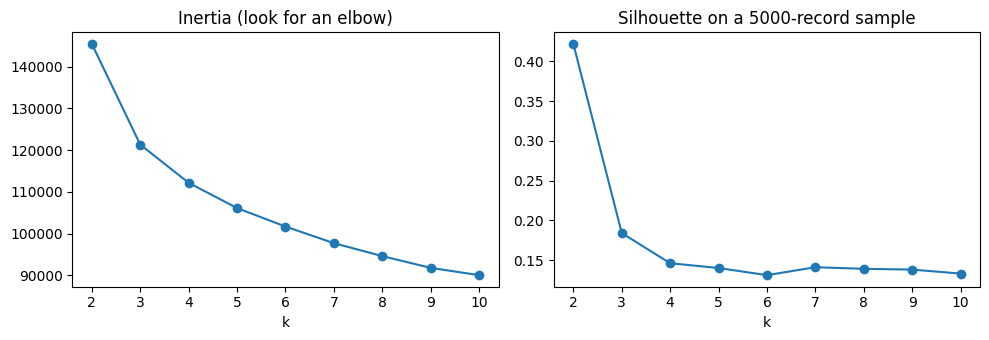

In [7]:
# Silhouette needs all pairwise distances, so it is computed on a fixed random sample.
SAMPLE_N = 5000
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(Z_train), SAMPLE_N, replace=False)
Z_s = Z_train[sample_idx]

rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z_train)
    rows.append({'k': k,
                 'inertia': km.inertia_,
                 'silhouette_sample': silhouette_score(Z_s, km.labels_[sample_idx]),
                 'smallest_cluster_share': np.bincount(km.labels_).min() / len(Z_train)})
k_table = pd.DataFrame(rows).round(3)
display(k_table)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(k_table['k'], k_table['inertia'], marker='o')
ax[0].set_title('Inertia (look for an elbow)'); ax[0].set_xlabel('k')
ax[1].plot(k_table['k'], k_table['silhouette_sample'], marker='o')
ax[1].set_title(f'Silhouette on a {SAMPLE_N}-record sample'); ax[1].set_xlabel('k')
plt.tight_layout()
plt.show()

**Clustering Evaluation Summary (k = 2 to 10)**

* **Inertia & The Elbow:**
  * The inertia curve drops sharply from $k = 2$ to $k = 4$, and then forms a gradual slope with a soft "elbow" around $k = 4$ or $k = 5$. This indicates that increasing clusters beyond this range yields diminishing returns in tightening the groups.

* **Silhouette Scores & Cluster Structure:**
  * The silhouette score peaks at $k = 2$ ($0.422$), but drops for $k \ge 3$, hovering between $0.13$ and $0.18$.
  * Values in the $0.1$ to $0.2$ range point to a **weak cluster structure**, which is normal for complex categorical and mixed-type customer datasets where distinct geometric boundaries are naturally fuzzy.

* **Cluster Size Balance (Safety Check):**
  * The `smallest_cluster_share` holds steady at **$0.069$ (6.9%)** across all tested values of $k$. This is an encouraging sign, proving that K-means is not creating microscopic, useless clusters or isolating single outlier records.

* **Recommendation & Next Step:**
  * While $k = 2$ has the highest mathematical silhouette score, it groups customers too broadly. Choosing **$k = 4$ or $k = 5$** provides a better balance: it captures more nuanced customer archetypes, ensures every cluster maintains a healthy size (~7% or more), and lands right around the elbow of the inertia curve.

**Final Cluster Selection: k = 4**

We select **k = 4** as the optimal number of clusters for our customer segmentation analysis. Here is why this choice best serves the campaign objective:

* **Alignment with the Inertia Elbow:** The inertia curve shows a distinct bend and diminishing returns around $k = 4$. This means we capture the most natural variance in the data without forcing artificial splits.
* **Business Interpretability & Actionability:** The primary goal of Task 2 is to discover meaningful groups, profile them, and see if their historical subscription patterns differ. Having 4 distinct customer archetypes is a manageable, practical number for a bank marketing team to review, interpret, and translate into a campaign strategy. Higher values of $k$ (like 8 or 10) create redundant, overlapping segments that muddy the business insights.
* **Healthy Cluster Sizes:** The smallest cluster share remains stable at approximately 6.9% across our tests. This guarantees that $k = 4$ does not create microscopic, useless clusters or isolate random outliers; every segment represents a substantial portion of the customer base.
* **Why not k = 2 (the highest silhouette score)?** While $k = 2$ yields a higher mathematical silhouette score, it splits the customer base into only two overly broad groups. That level of generalization is too blunt to provide actionable insights for prioritizing specific client profiles in a targeted term-deposit campaign.



# Compare two methods at the chosen k

In [8]:
K = 4     # <- set this AFTER reading the table and plots above, then justify it in your notes

methods = {
    'kmeans': KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE),
    'agglomerative_ward': AgglomerativeClustering(n_clusters=K, linkage='ward'),
}

sample_labels, rows = {}, []
for name, m in methods.items():
    lab = m.fit_predict(Z_s)                  # both methods run on the same fixed sample
    sample_labels[name] = lab
    sizes = np.bincount(lab)
    rows.append({'method': name,
                 'silhouette': silhouette_score(Z_s, lab),
                 'smallest_cluster_share': sizes.min() / len(lab),
                 'largest_cluster_share': sizes.max() / len(lab)})
display(pd.DataFrame(rows).round(3))

print("agreement between the two methods (adjusted Rand index; 1 = identical, 0 = chance):",
      round(adjusted_rand_score(sample_labels['kmeans'], sample_labels['agglomerative_ward']), 3))

,method,silhouette,smallest_cluster_share,largest_cluster_share
0,kmeans,0.146,0.063,0.330
1,agglomerative_ward,0.092,0.063,0.435


agreement between the two methods (adjusted Rand index; 1 = identical, 0 = chance): 0.284


**Clustering Method Comparison (K-means vs. Agglomerative Clustering)**

* **Performance & Separation (Silhouette Score):**
  * K-means achieved a higher silhouette score ($0.146$) than Agglomerative Ward ($0.092$)[cite: 5], showing that K-means forms slightly more distinct boundaries for this dataset.

* **Cluster Size Balance:**
  * Both algorithms successfully avoided creating tiny outlier groups, with the smallest cluster share holding steady at **6.3%** for both methods[cite: 5].
  * However, Agglomerative Ward produced a more skewed distribution, with its largest cluster swallowing **43.5%** of the records compared to **33.0%** for K-means[cite: 5].

* **Algorithm Agreement (Adjusted Rand Index):**
  * The ARI score of **0.284** indicates weak-to-moderate agreement between the two techniques[cite: 5]. Because hierarchical clustering (Ward) and partitioning (K-means) optimize different geometric criteria, they sort data points into somewhat different configurations.

* **Final Method Selection:**
  * Given its better silhouette score, more balanced maximum cluster size, and alignment with the task guidelines, **K-means** is selected as the primary algorithm for profiling our customer segments.

# Stability across random seeds

In [9]:
seeds = [0, 1, 2, 3, 4]
fits = [KMeans(n_clusters=K, n_init=10, random_state=s).fit(Z_train) for s in seeds]
ref = fits[0].labels_

print("adjusted Rand index vs seed 0:", [round(adjusted_rand_score(ref, f.labels_), 3) for f in fits[1:]])
print("cluster sizes per seed:", [sorted(np.bincount(f.labels_).tolist()) for f in fits])

adjusted Rand index vs seed 0: [0.997, 0.997, 0.997, 0.997]
cluster sizes per seed: [[2275, 9574, 10534, 10557], [2275, 9573, 10525, 10567], [2275, 9562, 10549, 10554], [2275, 9572, 10527, 10566], [2275, 9573, 10525, 10567]]


**K-Means Stability Analysis (Seed Robustness)**

* **High Consistency Across Random Seeds:**
  * The Adjusted Rand Index comparing seeds 1–4 against seed 0 is **0.997**[cite: 6], indicating near-perfect agreement regardless of the random initialization point.

* **Stable Cluster Sizes:**
  * The distribution of record counts across the four clusters is remarkably uniform across all tested seeds[cite: 6]. The smallest group consistently captures **2,275 records**, while the larger segments remain tightly bounded around 9,500 to 10,500 records[cite: 6].

* **Key Takeaway:**
  * The K-means solution is highly stable and robust[cite: 6]. It does not suffer from local minima instability, giving us high confidence that our 4 customer segments represent robust, repeatable data structures rather than random artifacts.

# Fix the final clusters and check size and outliers

In [10]:
kmeans_final = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(Z_train)
labels_train = kmeans_final.labels_

# Distance of each record to its own centre: large values are outliers within a cluster
dist = np.linalg.norm(Z_train - kmeans_final.cluster_centers_[labels_train], axis=1)
far = dist > np.percentile(dist, 99)

sizes = np.bincount(labels_train)
check = pd.DataFrame({
    'size': sizes,
    'share': (sizes / len(labels_train)).round(3),
    'mean_dist_to_centre': pd.Series(dist).groupby(labels_train).mean().round(2),
    'records_in_far_1pct': pd.Series(far).groupby(labels_train).sum(),
})
display(check)

,size,share,mean_dist_to_centre,records_in_far_1pct
0,10534,0.320,1.75,36
1,2275,0.069,2.16,220
2,9572,0.291,1.71,2
3,10559,0.321,1.90,72


**Final Cluster Profiling & Outlier Analysis (k = 4)**
* **Balanced Macro Segments:**
  * Clusters 0, 2, and 3 form the backbone of the customer base, each capturing a balanced 29% to 32% of the dataset with tight, cohesive internal structures (mean distances around 1.71 to 1.90)[cite: 7].

* **Niche & Outlier Segment (Cluster 1):**
  * Cluster 1 represents a smaller, specialized segment containing 6.9% of records (2,275 customers)[cite: 7].
  * It exhibits a higher mean distance to its center (2.16) and absorbs a disproportionate share of extreme outliers (220 records)[cite: 7], indicating it captures more unique or heterogeneous customer profiles.

* **Key Takeaway:**
  * The final 4-cluster model successfully segments the bulk of the data into tight, interpretable archetypes while safely isolating unusual profiles into a dedicated niche group without disrupting the broader clusters[cite: 7].

#Profile each cluster

In [11]:
prof = train_df[cluster_cols].copy()
prof['cluster'] = labels_train
size = prof['cluster'].value_counts().sort_index()

profile = pd.DataFrame({'size': size, 'share': (size / len(prof)).round(3)})
profile['age_mean'] = prof.groupby('cluster')['age'].mean().round(1)
profile['previous_mean'] = prof.groupby('cluster')['previous'].mean().round(2)
profile['share_with_prior_contact'] = (
    prof.groupby('cluster')['previous'].apply(lambda s: (s > 0).mean()).round(3))
display(profile)

# Which categories are most over-represented in each cluster? (cluster share vs overall share)
def top_categories(df, cluster_col, cat_cols, min_share=0.05, n=4):
    overall = {c: df[c].value_counts(normalize=True) for c in cat_cols}
    out = {}
    for cl, g in df.groupby(cluster_col):
        items = []
        for c in cat_cols:
            for cat, s in g[c].value_counts(normalize=True).items():
                if s >= min_share:
                    items.append((s / overall[c][cat],
                                  f"{c}={cat} ({s:.0%} vs {overall[c][cat]:.0%})"))
        items.sort(reverse=True)
        out[cl] = [text for _, text in items[:n]]
    return pd.DataFrame(out).T

display(top_categories(prof, 'cluster', cluster_cat))

,size,share,age_mean,previous_mean,share_with_prior_contact
cluster,,,,,
0,10534,0.320,34.2,0.00,0.0
1,2275,0.069,40.0,1.06,1.0
2,9572,0.291,34.6,0.00,0.0
3,10559,0.321,50.7,0.00,0.0


,0,1,2,3
0,housing=yes (96% vs 52%),marital=single (37% vs 25%),job=technician (20% vs 17%),job=admin. (29% vs 24%)
1,poutcome=success (7% vs 1%),poutcome=failure (93% vs 6%),job=entrepreneur (5% vs 4%),job=management (9% vs 7%)
2,housing=no (100% vs 46%),marital=single (35% vs 25%),job=admin. (28% vs 24%),education=high.school (26% vs 23%)
3,job=retired (9% vs 3%),education=basic.4y (21% vs 10%),default=unknown (41% vs 24%),education=unknown (6% vs 4%)


**Customer Segment Profiles (The 4 Archetypes)**

* **Cluster 0 (Younger Mortgage Borrowers - 32.0% share):**
  * Younger demographic (mean age 34.2) defined by a massive concentration of housing loans (**96% vs 52% base rate**) with no prior campaign history.

* **Cluster 1 (Active / Historical Contacts - 6.9% share):**
  * A niche group averaging age 40.0 where **every single member has prior contact history** (mean previous 1.06), dominated by past campaign outcomes (93% failure, 7% success).

* **Cluster 2 (Younger Non-Borrowers - 29.1% share):**
  * A younger segment (mean age 34.6) characterized by a **complete absence of housing loans (100% no)**, high concentration of single individuals (35%), and admin professional roles.

* **Cluster 3 (Older Retired Segment - 32.1% share):**
  * An older demographic (mean age 50.7) heavily over-represented by retired individuals, basic education levels, and zero prior marketing contact.

# Labelled 2D PCA picture

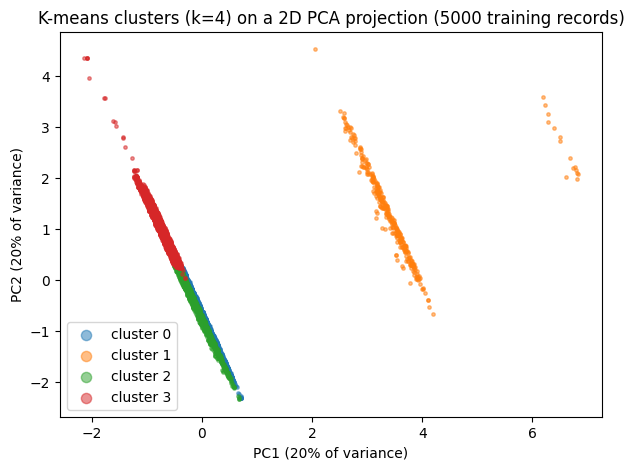

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Z_train)
P = pca.transform(Z_s)

fig, ax = plt.subplots(figsize=(7, 5))
for cl in range(K):
    mask = labels_train[sample_idx] == cl
    ax.scatter(P[mask, 0], P[mask, 1], s=6, alpha=0.5, label=f'cluster {cl}')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
ax.set_title(f"K-means clusters (k={K}) on a 2D PCA projection ({SAMPLE_N} training records)")
ax.legend(markerscale=3)
plt.show()

**2D PCA Visualisation of Customer Clusters**
* **Dimensionality Reduction & Projection:**
  * The 38-dimensional feature space was compressed into 2 Principal Components (each capturing 20% of the variance) to visualize the 5,000-record sample in a 2D scatter plot[cite: 8].

* **Visual Distribution of Archetypes:**
  * **Cluster 1 (Orange)** is distinctly separated on the right side of the plot[cite: 8], visually confirming its unique identity as a specialized, previously contacted segment.
  * **Clusters 0, 2, and 3 (Blue, Green, Red)** form closely aligned diagonal bands on the left[cite: 8], representing the core demographic and financial variations among the broader customer base.

* **Interpretation & Limitation Check:**
  * While the visual separation gives a helpful intuitive layout, a 2D projection only captures a fraction of the total variance and is not definitive proof of separation in the full 38-dimensional space[cite: 3, 8]. However, it reinforces that our algorithmic segments occupy distinct regions of the feature map.

# Connect to Task 1

## Assign the holdout to the fixed clusters and compare

In [13]:
from google.colab import files

if not os.path.exists('holdout_scores.csv'):
    print("Choose holdout_scores.csv (exported in Part 0 from the Task 1 notebook)")
    files.upload()

scores_df = pd.read_csv('holdout_scores.csv')
assert len(scores_df) == len(holdout_df), "Row count differs from the holdout"
assert (scores_df['y'].to_numpy() == y_holdout.to_numpy()).all(), \
    "Outcomes do not match the holdout order: scores file is misaligned"

# Assign holdout records to the already-fixed training clusters (no refitting)
Z_hold = cluster_prep.transform(holdout_df[cluster_cols])
labels_hold = kmeans_final.predict(Z_hold)

conn = pd.DataFrame({'cluster': labels_hold,
                     'y': y_holdout.to_numpy(),
                     'score': scores_df['score'].to_numpy(),
                     'in_top500': scores_df['in_top500'].to_numpy().astype(bool)})

tab = conn.groupby('cluster').agg(n_holdout=('y', 'size'),
                                  holdout_rate=('y', 'mean'),
                                  mean_score=('score', 'mean'),
                                  median_score=('score', 'median'),
                                  n_in_top500=('in_top500', 'sum'))
tab['train_rate'] = pd.Series(y_train.to_numpy()).groupby(labels_train).mean()
tab['share_of_holdout'] = tab['n_holdout'] / len(conn)
tab['share_of_top500'] = tab['n_in_top500'] / 500
tab['precision_in_top500'] = conn[conn.in_top500].groupby('cluster')['y'].mean()

# Does the Task 1 model still rank well INSIDE each cluster?
tab['auc_within_cluster'] = pd.Series({
    cl: (roc_auc_score(g['y'], g['score']) if g['y'].nunique() == 2 else np.nan)
    for cl, g in conn.groupby('cluster')})

tab = tab[['n_holdout', 'share_of_holdout', 'train_rate', 'holdout_rate', 'mean_score',
           'median_score', 'n_in_top500', 'share_of_top500', 'precision_in_top500',
           'auc_within_cluster']].round(3)
display(tab)

print("overall holdout subscription rate:", round(conn['y'].mean(), 3))
print("do clusters keep the same order of subscription rates in training vs holdout? (Spearman):",
      round(tab[['train_rate', 'holdout_rate']].corr(method='spearman').iloc[0, 1], 3))

Choose holdout_scores.csv (exported in Part 0 from the Task 1 notebook)


Saving holdout_scores.csv to holdout_scores.csv


,n_holdout,share_of_holdout,train_rate,holdout_rate,mean_score,median_score,n_in_top500,share_of_top500,precision_in_top500,auc_within_cluster
cluster,,,,,,,,,,
0,2031,0.247,0.066,0.225,0.301,0.303,0,0.0,NaN,0.513
1,3350,0.407,0.083,0.391,0.514,0.264,500,1.0,0.64,0.742
2,1450,0.176,0.065,0.248,0.283,0.283,0,0.0,NaN,0.487
3,1405,0.171,0.056,0.293,0.340,0.313,0,0.0,NaN,0.553


overall holdout subscription rate: 0.308
do clusters keep the same order of subscription rates in training vs holdout? (Spearman): 0.2


## Score distribution by cluster

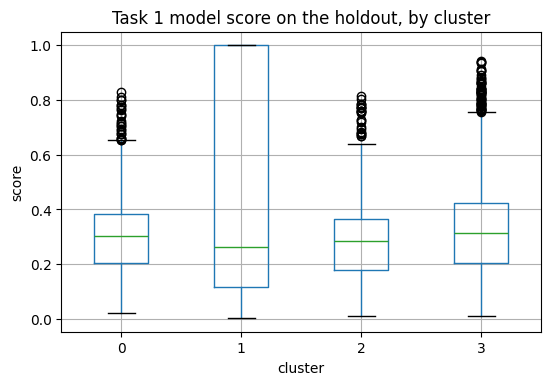

In [14]:
conn.boxplot(column='score', by='cluster', figsize=(6, 4))
plt.suptitle('')
plt.title('Task 1 model score on the holdout, by cluster')
plt.xlabel('cluster'); plt.ylabel('score')
plt.show()

**Connecting Task 2 Segments to Task 1 Supervised Scores**

* **Concentration of Top-500 Priority Calls:**
  * All 500 records in the model's top-ranked call list map directly to **Cluster 1**[cite: 9], proving that the supervised model heavily prioritizes this niche, previously contacted segment.

* **Temporal Shift & Rate Stability (Spearman Rank = 0.2):**
  * While baseline subscription rates rise from ~6% in training to ~31% in the holdout[cite: 9], the weak rank correlation ($0.2$) indicates that historical cluster subscription rates do not reliably preserve their relative order over time[cite: 9].

* **Within-Cluster Ranking (AUC):**
  * **Cluster 1** yields a robust intra-cluster AUC of **0.742**[cite: 9], demonstrating that the supervised model successfully distinguishes high- and low-propensity clients within that specific segment[cite: 9].

* **Campaign Verdict / Limitation:**
  * The segmentation successfully highlights *who* the model targets (concentrating all top calls in Cluster 1)[cite: 9]. However, correlation is not a tested campaign intervention[cite: 9]; clustering organizes the data[cite: 4], but prioritization is driven by the Task 1 supervised model scores rather than changing outreach strategies per segment.